In [ ]:
"""
mo_calculate_eregulon_enrichments.ipynb

This script is calculate the enrichment scores of eRegulons for different metadata parameters

authors: Roy Oelen

"""

In [39]:
###########
# imports #
###########

# for path operations
import os
import glob
from pathlib import Path
# for reading the output of SCENIC+
import scanpy as sc
import anndata
import mudata
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)
# for saving results
import joblib
# for visualizing results
import pandas as pd


In [3]:
###################
# paths of inputs #
###################

# location of the mu that has the eregulon data
eregulon_mu_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/scplus_pipeline_merged_major_and_minor_celltypes/output/scplusmdata.h5mu'


In [4]:
###################
# load the inputs #
###################

# read the scenic output metadata
scplus_mdata = mudata.read(eregulon_mu_loc)


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be remo

In [5]:
#######################################
# process eRegulons data based on AUC #
#######################################

# merge the direct and extended
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)
# add the cell names
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]

In [13]:
# do Scanpy preprocessing steps to get to clusters and umap for the eRegulon scores
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")
sc.tl.umap(eRegulon_gene_AUC)


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
##################################################
# calculate the RSS based on the major cell type #
##################################################

# based on the RNA cell types, get the scores
rss_ct_major = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:celltype_imputed_lowerres",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)


In [15]:
##################################################
# calculate the RSS based on the minor cell type #
##################################################

# based on the RNA cell types, get the scores
rss_ct_minor = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:predicted.mo_10x_cell_type",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)


In [33]:
#####################################################
# calculate the RSS based on the stimulation status #
#####################################################

# based on the RNA cell types, get the scores
rss_condition = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:condition_final",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)


In [34]:
####################################################################
# calculate the RSS based on the lane, to check for batch efffects #
####################################################################

# based on the RNA cell types, get the scores
rss_lane = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:lane",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)


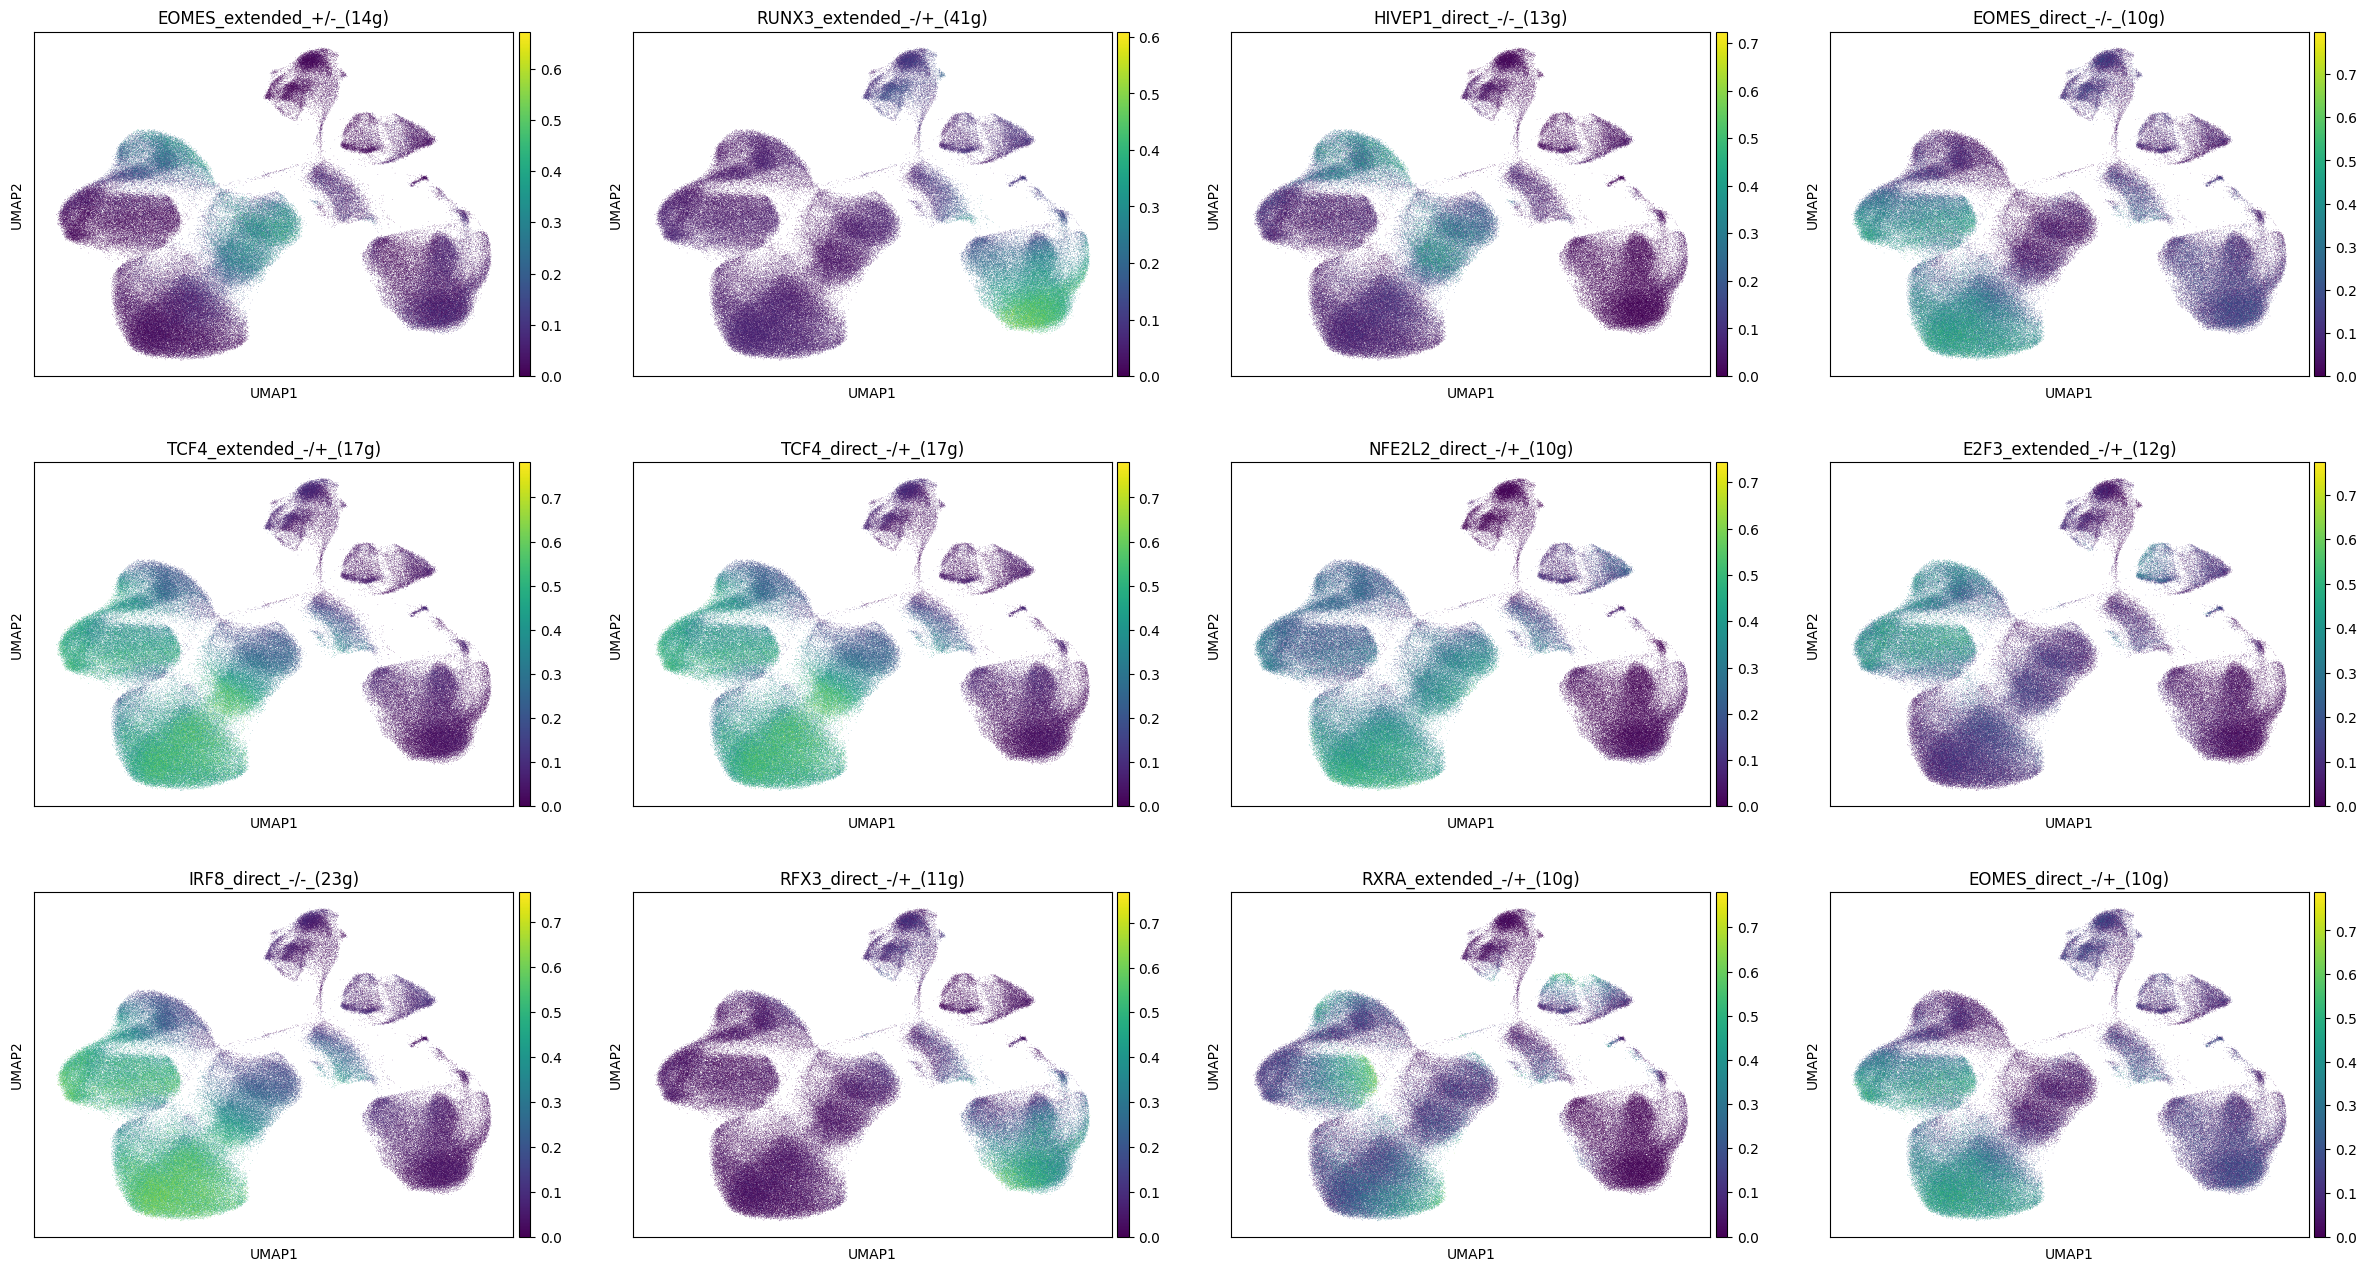

In [18]:
###############################
# plot the specificity scores #
###############################

# plot the major cell types
sc.pl.umap(eRegulon_gene_AUC, color = list(set([x for xs in [rss_ct_major.loc[ct].sort_values()[0:2].index for ct in rss_ct_major.index] for x in xs ])))


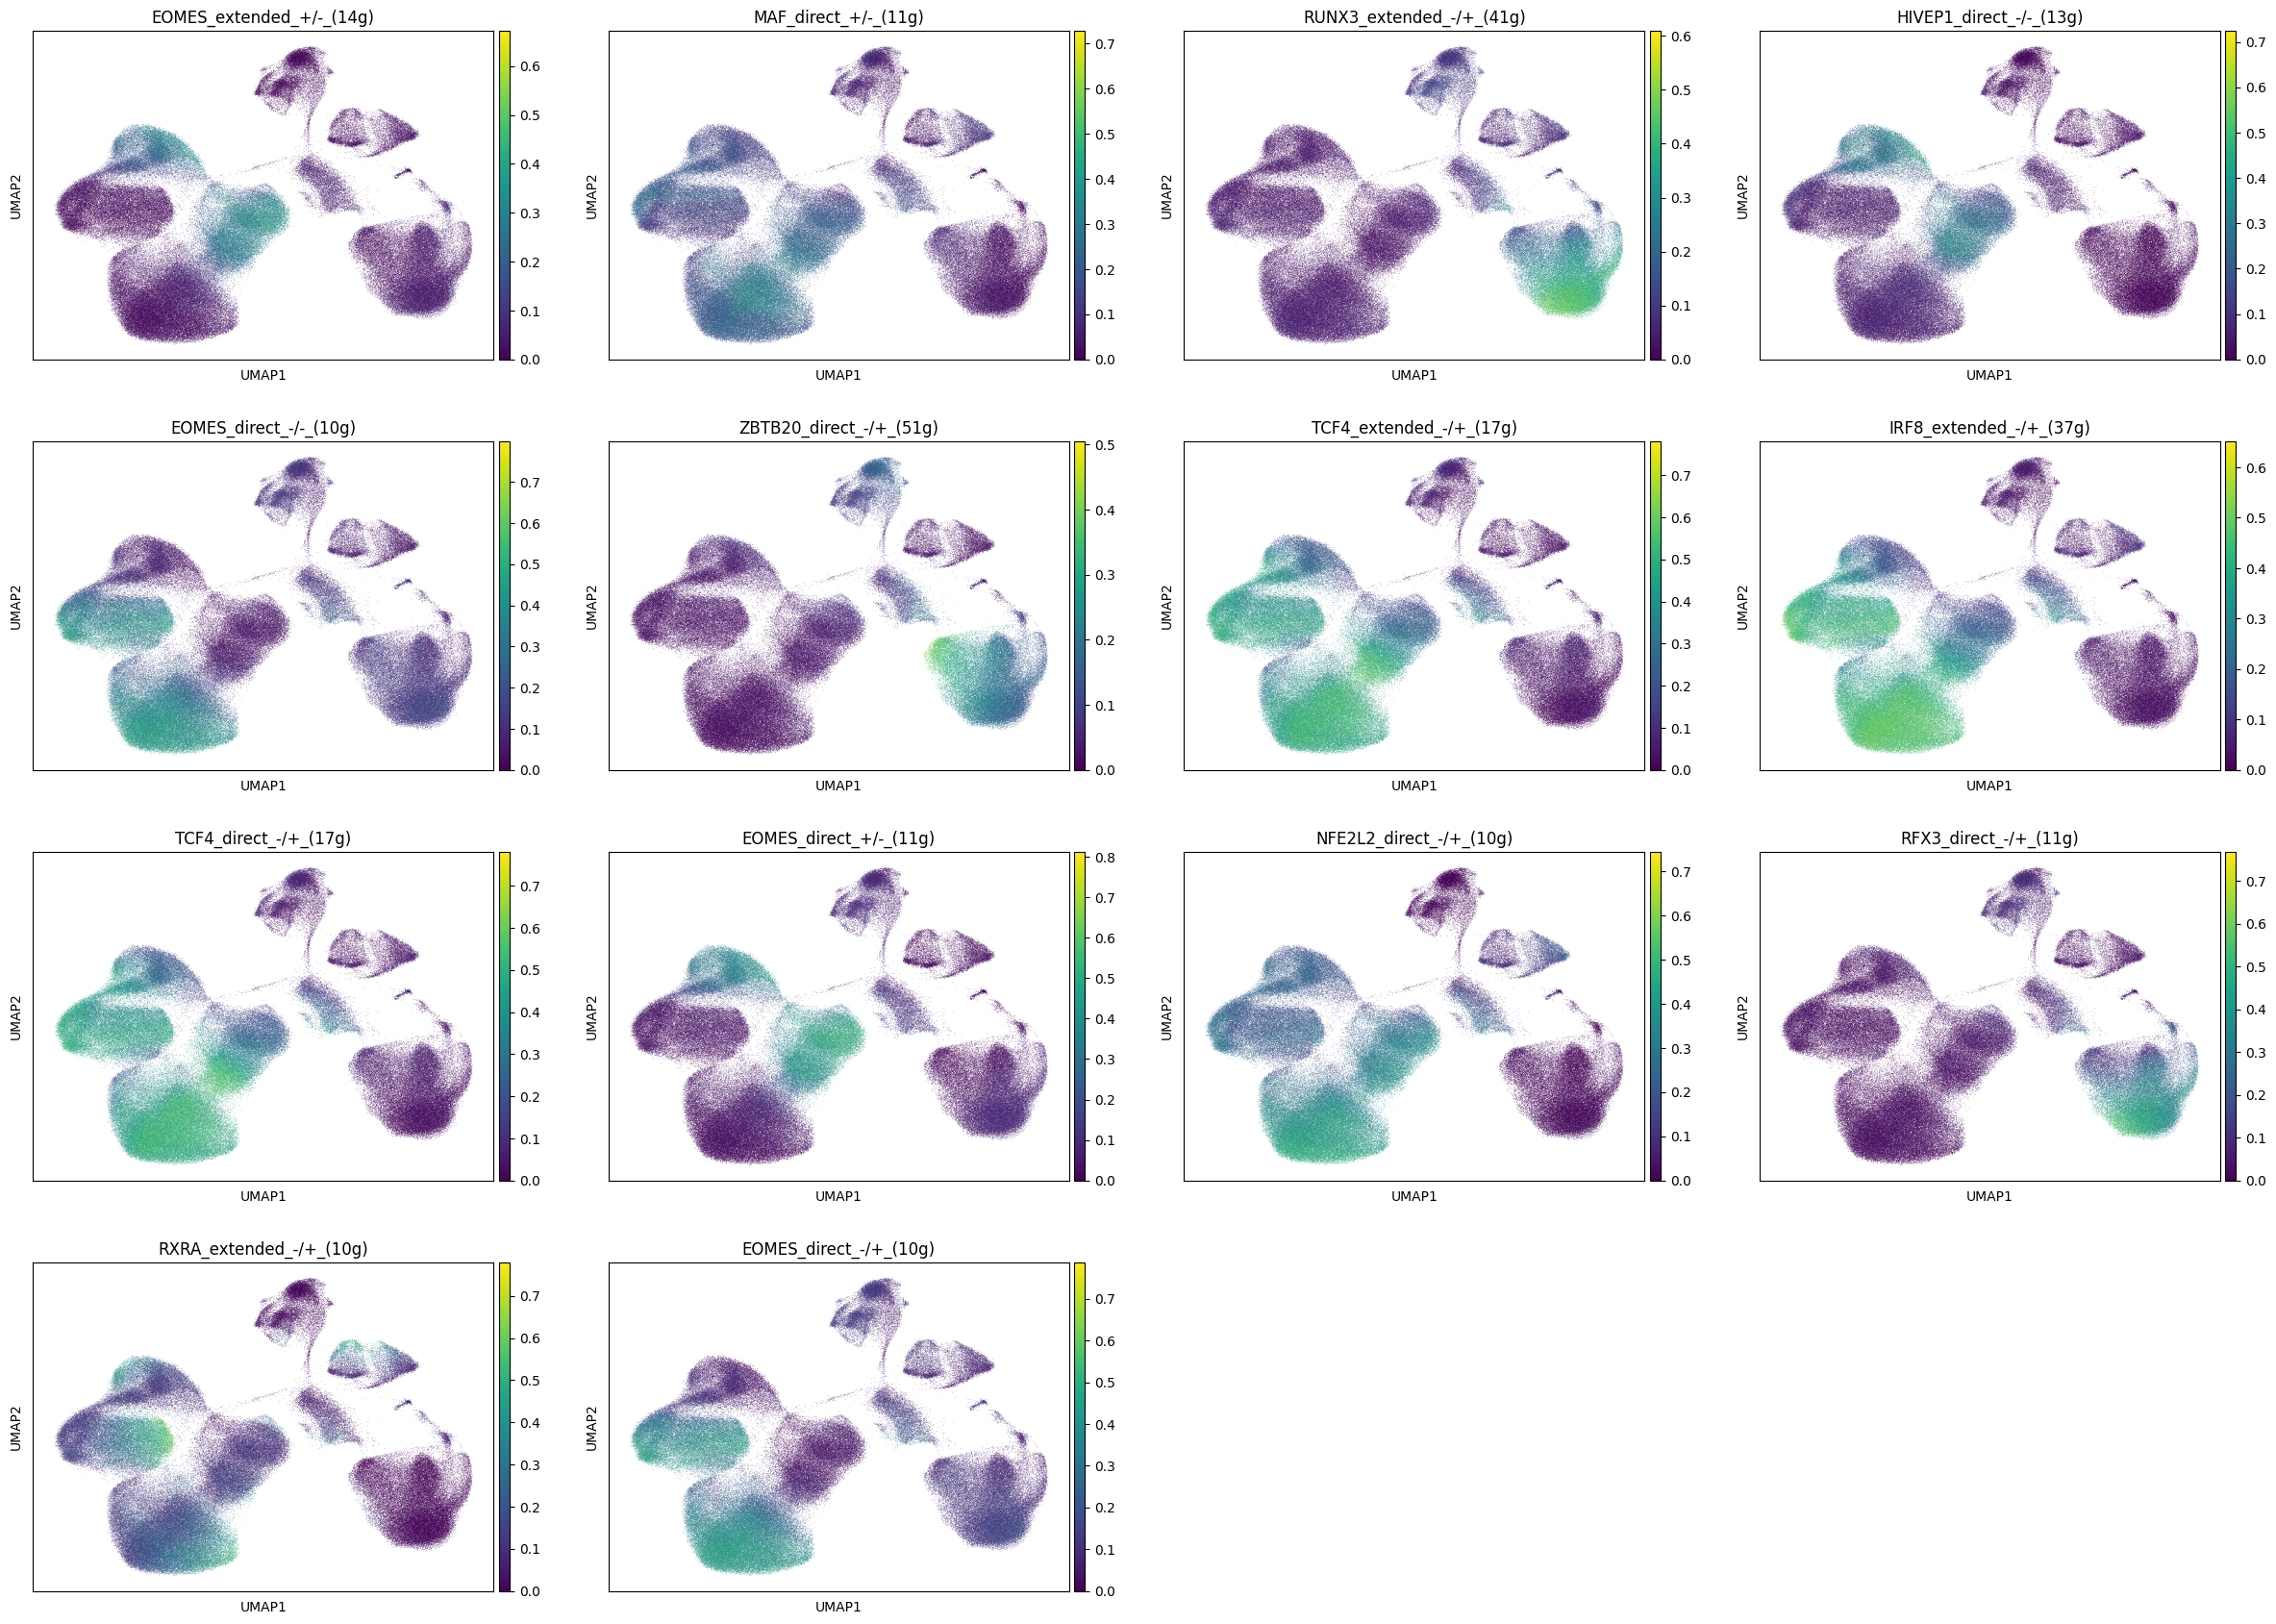

In [19]:
# plot the minor cell types
sc.pl.umap(eRegulon_gene_AUC, color = list(set([x for xs in [rss_ct_minor.loc[ct].sort_values()[0:2].index for ct in rss_ct_minor.index] for x in xs ])))


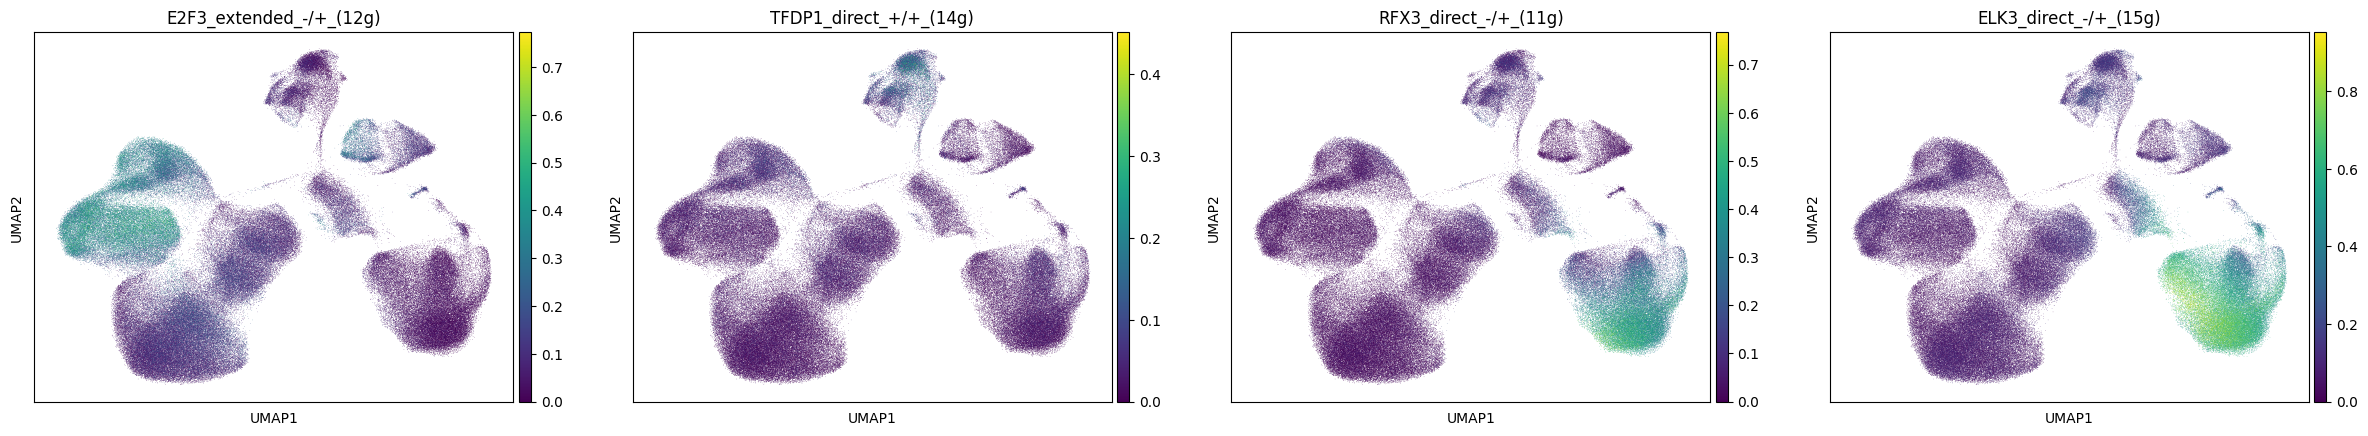

In [20]:
# and the stimulation status
sc.pl.umap(eRegulon_gene_AUC, color = list(set([x for xs in [rss_condition.loc[ct].sort_values()[0:2].index for ct in rss_condition.index] for x in xs ])))


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


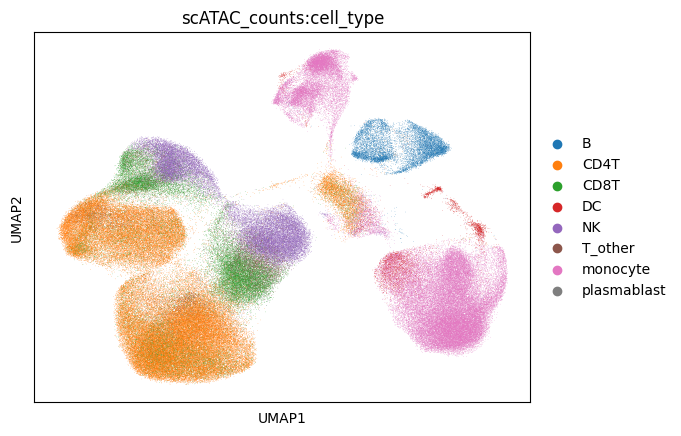

In [46]:
# compared to the UMAP coloured by the major cell type
sc.pl.umap(eRegulon_gene_AUC, color = "scATAC_counts:cell_type")


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


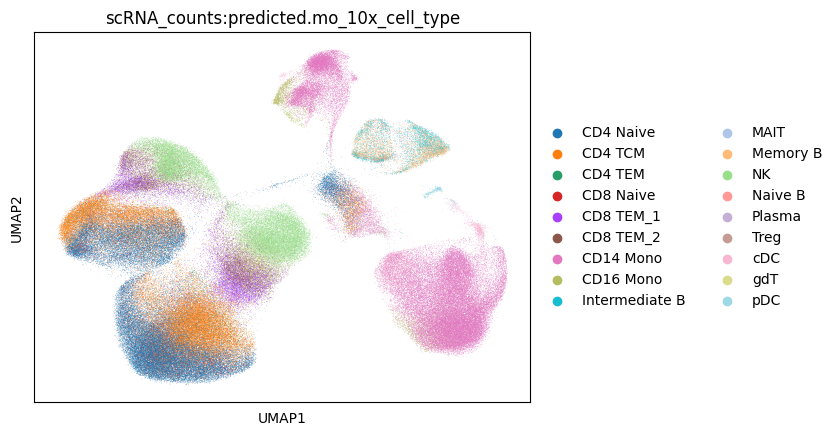

In [47]:
# compared to the UMAP coloured by the minor cell type
sc.pl.umap(eRegulon_gene_AUC, color = "scRNA_counts:predicted.mo_10x_cell_type")


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


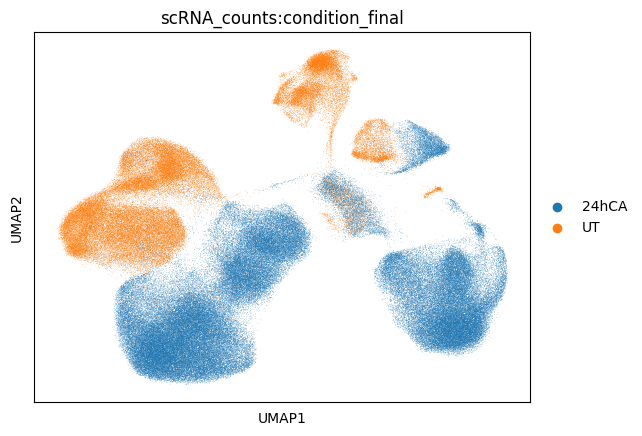

In [48]:
# compared to the UMAP coloured by the stimulation condition
sc.pl.umap(eRegulon_gene_AUC, color = "scRNA_counts:condition_final")


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


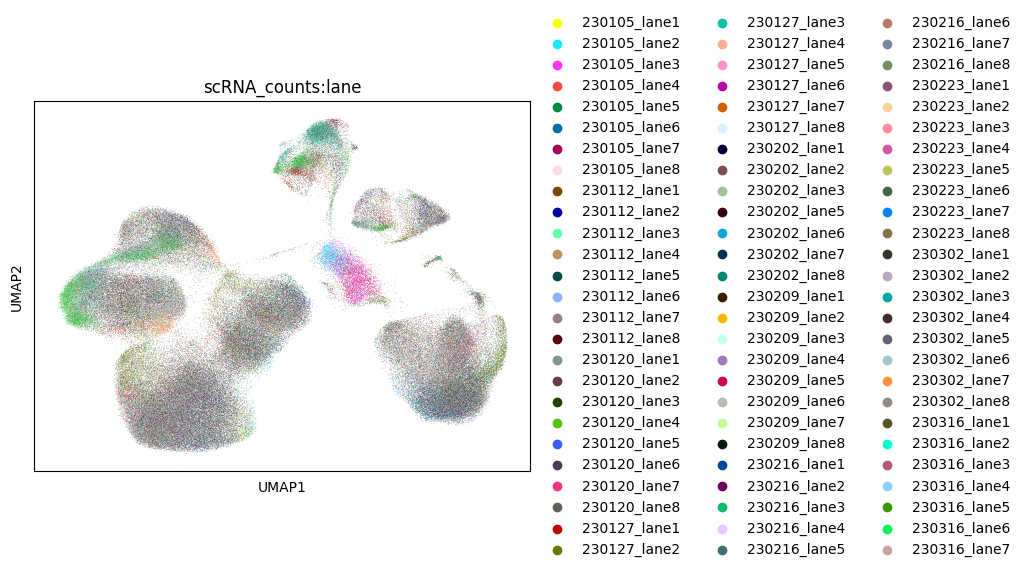

In [35]:
# compared to the UMAP coloured by the lane
sc.pl.umap(eRegulon_gene_AUC, color = "scRNA_counts:lane")


In [36]:
# check what the RSS table looks like
rss_ct_major


,ARID3A_direct_+/+_(261g),ATF5_direct_+/+_(428g),ATF5_direct_+/-_(200g),ATF5_direct_-/-_(11g),ATF6_direct_+/-_(60g),BACH1_direct_+/+_(1425g),BACH1_direct_+/-_(731g),BACH1_direct_-/+_(251g),BACH1_direct_-/-_(245g),BACH2_direct_+/+_(403g),...,STAT5B_extended_+/+_(76g),STAT6_extended_+/-_(20g),TBX21_extended_+/+_(95g),TBX21_extended_+/-_(17g),TCF4_extended_+/+_(267g),TCF4_extended_-/+_(17g),TCF7_extended_+/+_(364g),TCF7_extended_-/-_(108g),ZBTB43_extended_+/+_(66g),ZBTB7A_extended_+/-_(16g)
NK,0.252140,0.257137,0.256850,0.318072,0.276537,0.264352,0.261829,0.305459,0.304348,0.276269,...,0.288992,0.270923,0.435751,0.451972,0.272583,0.279555,0.268145,0.321647,0.299626,0.329383
DC,0.188283,0.189683,0.188664,0.172102,0.183956,0.185675,0.185612,0.175785,0.175783,0.178585,...,0.176294,0.187646,0.181305,0.179784,0.204089,0.171038,0.176746,0.185999,0.182570,0.179343
CD4T,0.332518,0.361569,0.356473,0.556923,0.466739,0.386075,0.374296,0.581983,0.580861,0.587532,...,0.572142,0.371200,0.371226,0.294499,0.402664,0.625277,0.609728,0.286978,0.388078,0.375962
monocyte,0.593724,0.553821,0.558382,0.242431,0.424515,0.534224,0.549054,0.222825,0.220071,0.276205,...,0.285208,0.468037,0.308805,0.323359,0.432511,0.203601,0.274037,0.547486,0.477010,0.399137
CD8T,0.233937,0.239298,0.240928,0.308126,0.261646,0.248788,0.246168,0.305076,0.303120,0.276372,...,0.295028,0.251838,0.329241,0.314369,0.254982,0.311539,0.273939,0.272808,0.267624,0.295832
T_other,0.180419,0.182094,0.182624,0.193557,0.186664,0.183610,0.182949,0.194046,0.194111,0.188482,...,0.193962,0.185715,0.199318,0.196271,0.184919,0.197536,0.190308,0.185144,0.186119,0.192346
unannotated,0.207015,0.199462,0.199391,0.193049,0.196869,0.200426,0.200487,0.195224,0.195660,0.196130,...,0.194866,0.199669,0.195192,0.193535,0.204335,0.194093,0.195922,0.200716,0.199820,0.196361
B,0.211761,0.209203,0.205892,0.192431,0.222225,0.213814,0.212356,0.215455,0.216137,0.231050,...,0.203990,0.239425,0.207923,0.208903,0.303063,0.176642,0.212906,0.218727,0.206395,0.202759
plasmablast,0.170133,0.169969,0.169952,0.170200,0.170622,0.170147,0.170120,0.170865,0.170996,0.171063,...,0.170498,0.171188,0.169937,0.169519,0.172049,0.170110,0.171096,0.169916,0.170223,0.170427


In [45]:
#####################################
# get max column for each rss table #
#####################################

# check most enriched lane for each TF
tf_to_lane = rss_lane.idxmax().to_frame()
# rename the column
tf_to_lane = tf_to_lane.rename(mapper={0 : 'lane'}, axis = 1)
# and check which are showing an association with our bad lanes
print(tf_to_lane[(tf_to_lane['lane'] == '230105_lane2') | (tf_to_lane['lane'] == '230105_lane3')].to_string())


Empty DataFrame
Columns: [lane]
Index: []
